In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans


In [2]:
df = pd.read_csv("/Users/sujana/Documents/Sujana_personal/BA_Hackathon_1142/bank_transactions.csv")

# Clean column names
df.columns = df.columns.str.replace(" ", "")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")

df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmountINR
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [3]:
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], errors='coerce')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d/%m/%y')

df['TransactionTime'] = df['TransactionTime'].astype(str).str.zfill(6)
df['Hour'] = df['TransactionTime'].str[:2].astype(int)

df['Age'] = (df['TransactionDate'] - df['CustomerDOB']).dt.days / 365
df['Age'] = df['Age'].fillna(df['Age'].median())



/var/folders/hz/j2c8cf2n587d_cs44qq449dw0000gn/T/ipykernel_25598/1526162855.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], errors='coerce')


In [4]:
# Spending relative to balance
df['Balance_Ratio'] = df['TransactionAmountINR'] / (df['CustAccountBalance'] + 1)

# Late night flag
df['Late_Night'] = df['Hour'].apply(lambda x: 1 if x >= 23 or x <= 4 else 0)

# Weekend flag
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek
df['Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

In [5]:
customer_df = df.groupby('CustomerID').agg({
    'TransactionAmountINR':'mean',
    'Balance_Ratio':'mean',
    'Late_Night':'mean',
    'Weekend':'mean',
    'CustAccountBalance':'mean',
    'Age':'mean'
}).reset_index()

# Add variability
customer_df['Spend_Variability'] = df.groupby('CustomerID')['TransactionAmountINR'].std().values

customer_df.fillna(0, inplace=True)

customer_df.head()

,CustomerID,TransactionAmountINR,Balance_Ratio,Late_Night,Weekend,CustAccountBalance,Age,Spend_Variability
0,C1010011,2553.0,0.074554,0.5,0.0,76340.635,28.700000,3107.027197
1,C1010012,1499.0,0.061928,0.0,1.0,24204.490,22.063014,0.000000
2,C1010014,727.5,0.016471,0.0,0.5,100112.950,28.163014,675.286976
3,C1010018,30.0,0.060340,0.0,0.0,496.180,26.317808,0.000000
4,C1010024,5000.0,0.057432,0.0,0.0,87058.650,-48.873973,0.000000


In [6]:
features = customer_df.drop('CustomerID', axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(scaled_features)

customer_df['Cluster'].value_counts()

Cluster
2    544484
0    270846
1     67415
3      1520
Name: count, dtype: int64

In [7]:
cluster_summary = customer_df.groupby('Cluster')[[
    'TransactionAmountINR',
    'Balance_Ratio',
    'Late_Night',
    'Weekend',
    'CustAccountBalance',
    'Age',
    'Spend_Variability',
]].mean()
cluster_summary

,TransactionAmountINR,Balance_Ratio,Late_Night,Weekend,CustAccountBalance,Age,Spend_Variability
Cluster,,,,,,,
0,1565.218285,8.466466,0.003788,0.911824,118332.909510,28.352673,293.657542
1,1222.160371,8.024295,0.890843,0.297358,106853.345228,32.381732,271.711686
2,1482.089784,8.165134,0.001531,0.004819,113497.427570,30.687285,157.236863
3,52121.382422,1774.449776,0.045910,0.296371,386385.741676,40.069585,40121.066519


In [10]:
risk_features = [
    'Balance_Ratio',
    'Spend_Variability',
    'Late_Night',
    'Weekend'
]

# Normalize each risk component
minmax = MinMaxScaler()
normalized = minmax.fit_transform(customer_df[risk_features])

customer_df['Risk_Score'] = normalized.mean(axis=1) * 100

customer_df[['CustomerID','Cluster','Risk_Score']].head()

,CustomerID,Cluster,Risk_Score
0,C1010011,1,12.651789
1,C1010012,0,25.000012
2,C1010014,0,12.532990
3,C1010018,2,0.000012
4,C1010024,2,0.000011


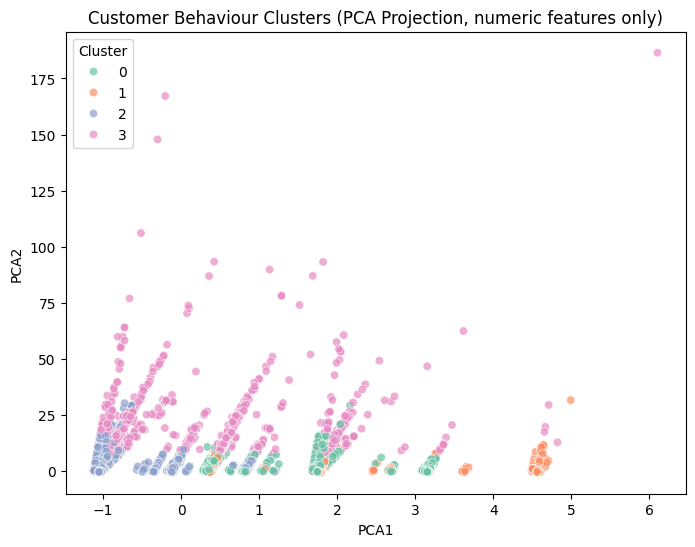

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns and drop cluster label
numeric_features = customer_df.select_dtypes(include=["number"])
features = numeric_features.drop(columns=["Cluster"], errors="ignore")

# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# PCA to 2 components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# Add PCA results to dataframe
customer_df["PCA1"] = principal_components[:, 0]
customer_df["PCA2"] = principal_components[:, 1]

# Plot PCA projection coloured by cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    data=customer_df,
    alpha=0.7,
)
plt.title("Customer Behaviour Clusters (PCA Projection, numeric features only)")
plt.show()

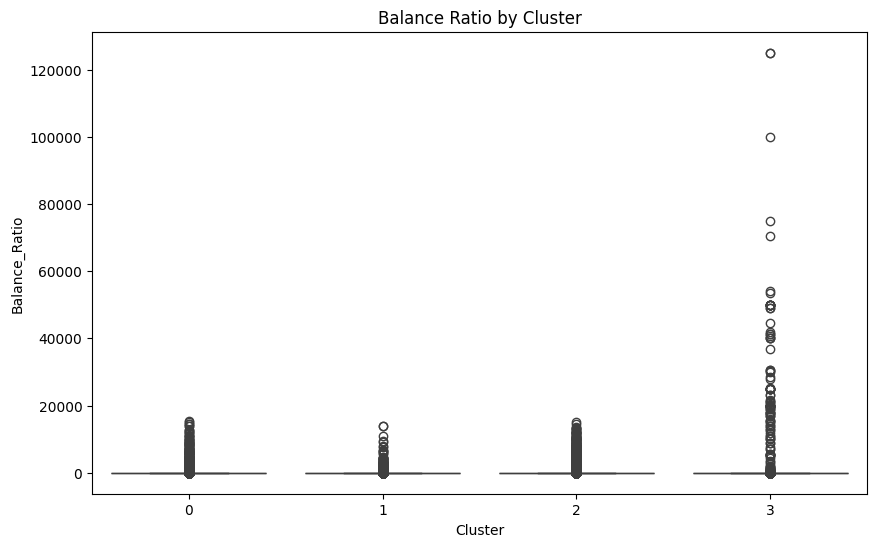

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Cluster', y='Balance_Ratio', data=customer_df)
plt.title("Balance Ratio by Cluster")
plt.show()

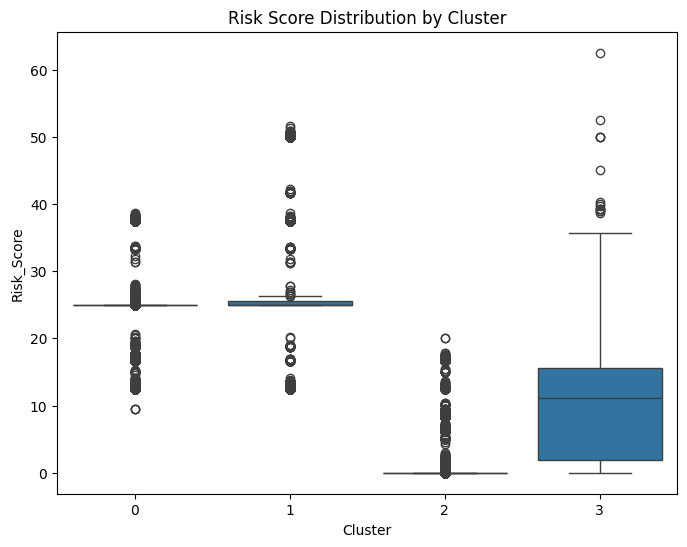

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Cluster', y='Risk_Score', data=customer_df)
plt.title("Risk Score Distribution by Cluster")
plt.show()

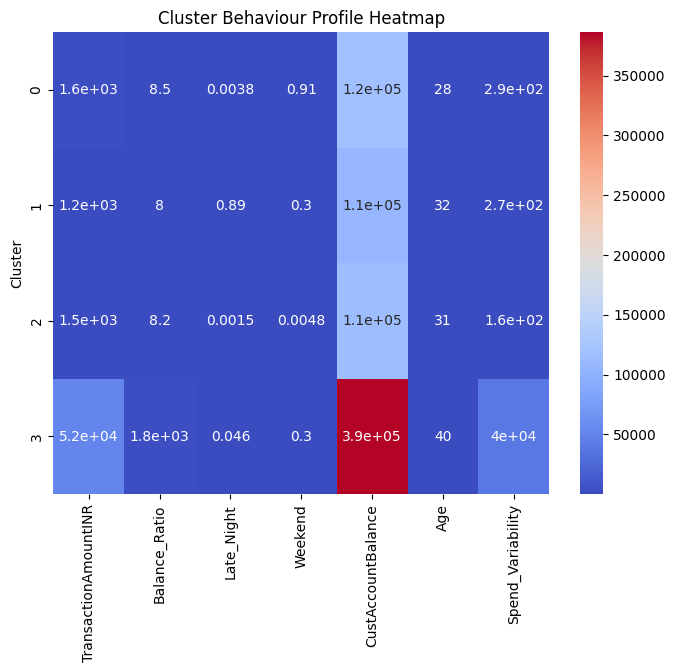

In [22]:
cluster_summary = customer_df.groupby('Cluster')[[
    'TransactionAmountINR',
    'Balance_Ratio',
    'Late_Night',
    'Weekend',
    'CustAccountBalance',
    'Age',
    'Spend_Variability',
]].mean()

plt.figure(figsize=(8,6))
sns.heatmap(cluster_summary, annot=True, cmap='coolwarm')
plt.title("Cluster Behaviour Profile Heatmap")
plt.show()

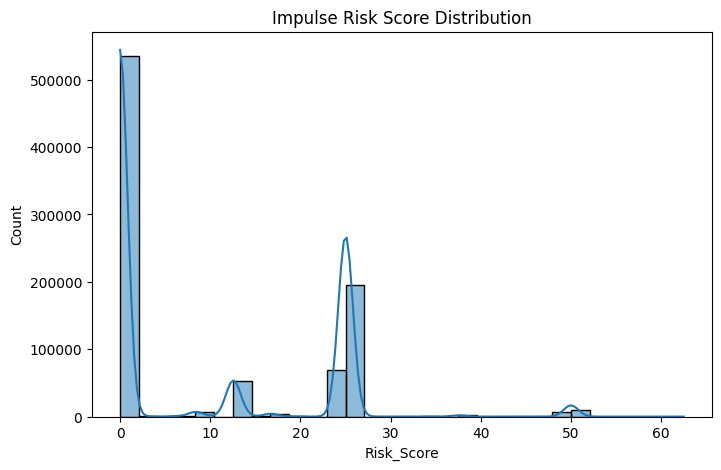

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(customer_df['Risk_Score'], bins=30, kde=True)
plt.title("Impulse Risk Score Distribution")
plt.show()

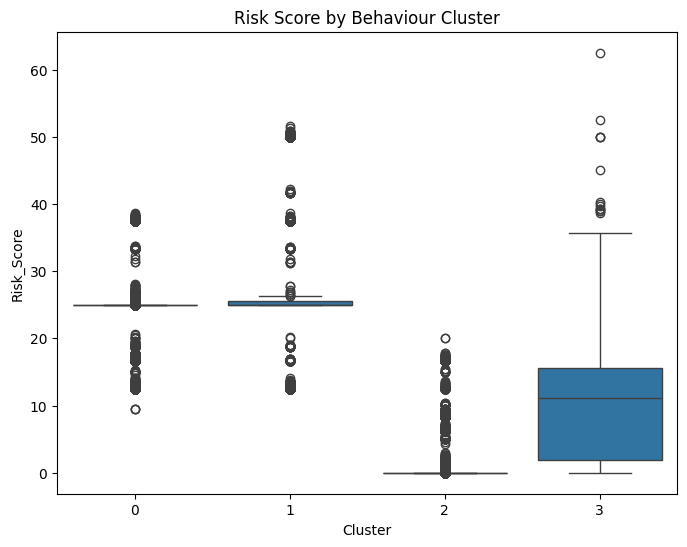

In [24]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Cluster', y='Risk_Score', data=customer_df)
plt.title("Risk Score by Behaviour Cluster")
plt.show()

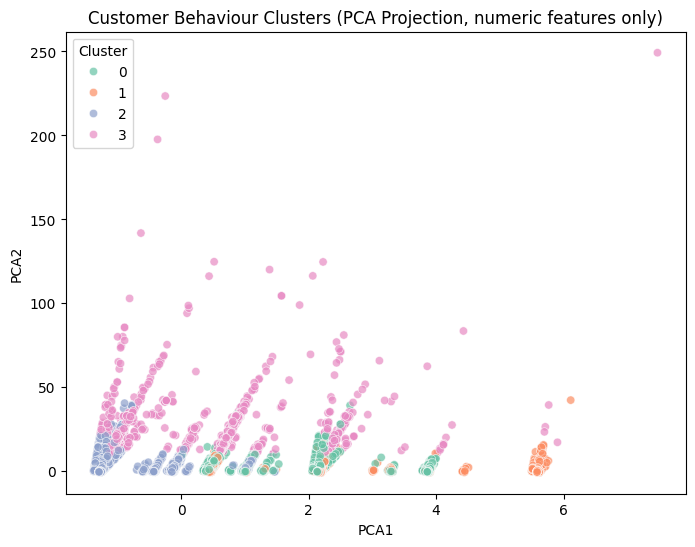

In [25]:
# Re-run PCA using only numeric features (exclude cluster label)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns and drop cluster label
numeric_features = customer_df.select_dtypes(include=["number"])
features = numeric_features.drop(columns=["Cluster"], errors="ignore")

# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# PCA to 2 components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# Add PCA results to dataframe
customer_df["PCA1"] = principal_components[:, 0]
customer_df["PCA2"] = principal_components[:, 1]

# Plot PCA projection coloured by cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    data=customer_df,
    alpha=0.7,
)
plt.title("Customer Behaviour Clusters (PCA Projection, numeric features only)")
plt.show()

In [26]:
def generate_nudge(score):
    if score > 70:
        return "High impulse tendency: Recommend spending alerts."
    elif score > 40:
        return "Moderate impulse behaviour: Suggest budgeting tools."
    else:
        return "Low impulse behaviour: Financial habits stable."

customer_df['Behavioural_Nudge'] = customer_df['Risk_Score'].apply(generate_nudge)

customer_df[['CustomerID','Risk_Score','Behavioural_Nudge']].head()

,CustomerID,Risk_Score,Behavioural_Nudge
0,C1010011,12.651789,Low impulse behaviour: Financial habits stable.
1,C1010012,25.000012,Low impulse behaviour: Financial habits stable.
2,C1010014,12.532990,Low impulse behaviour: Financial habits stable.
3,C1010018,0.000012,Low impulse behaviour: Financial habits stable.
4,C1010024,0.000011,Low impulse behaviour: Financial habits stable.
